Top Selected Features via RFE: ['Bathrooms', 'Floors', 'Location_Suburban', 'Location_Urban', 'Condition_Fair']

Model Performance:
                            RMSE            MAE        R²
Linear Regression  279859.725838  243241.977588 -0.006718
Decision Tree      405125.080762  332170.070000 -1.109625
XGBoost            320186.416102  273183.312500 -0.317749


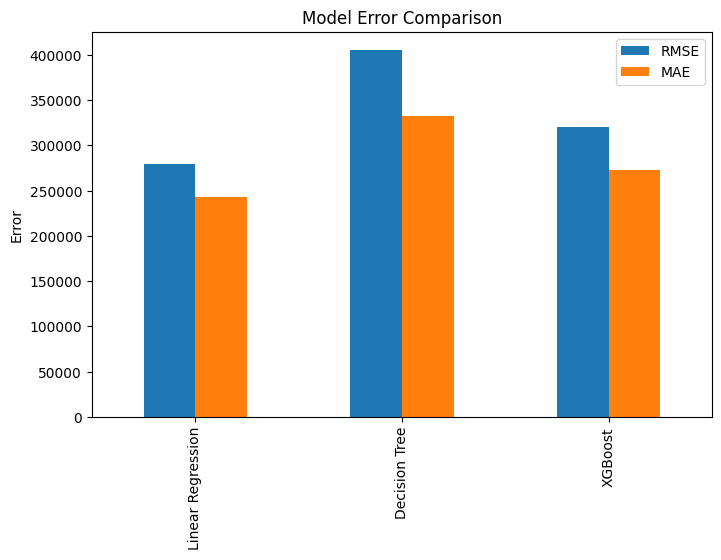

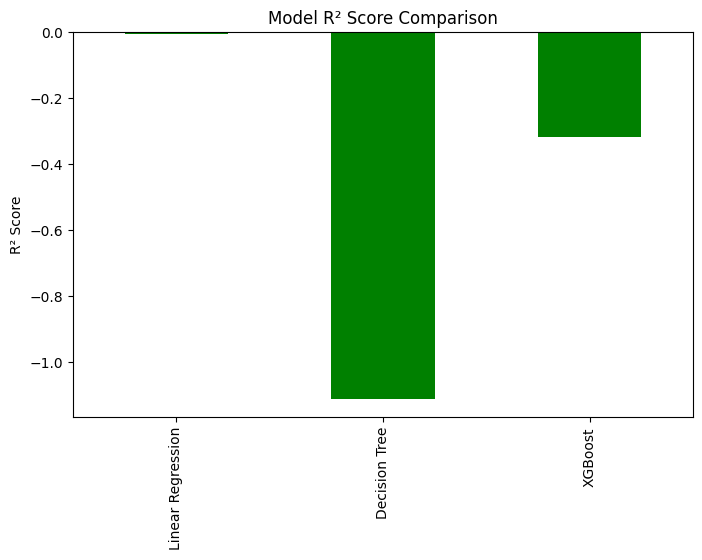

In [4]:
#House price prediction
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import RFE
from xgboost import XGBRegressor
file_path = "/content/House Price Prediction Dataset.csv"
df = pd.read_csv(file_path)
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)
target = 'Price'
X = df.drop(columns=[target])
y = df[target]
num_features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']
cat_features = ['Location', 'Condition', 'Garage']
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=100)
}
results = {}
for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"RMSE": rmse, "MAE": mae, "R²": r2}
X_processed = pd.get_dummies(X, drop_first=True)
base_model = LinearRegression()
n_features = min(5, X_processed.shape[1])  # choose top 5 or less
selector = RFE(base_model, n_features_to_select=n_features)
selector.fit(X_processed, y)
selected_features = X_processed.columns[selector.support_]
print("Top Selected Features via RFE:", selected_features.tolist())
results_df = pd.DataFrame(results).T
print("\nModel Performance:")
print(results_df)
results_df[['RMSE','MAE']].plot(kind='bar', figsize=(8,5))
plt.title('Model Error Comparison')
plt.ylabel('Error')
plt.show()
results_df['R²'].plot(kind='bar', color='green', figsize=(8,5))
plt.title('Model R² Score Comparison')
plt.ylabel('R² Score')
plt.show()
